## Автоэнкодеры

### 1. Понятие автоэнкодера

Автоэнкодер — особый тип архитектуры НС, выполняющие последовательно кодирование входных данных (уменьшение размерности) в некоторое скрытое представление (latent layer), затем декодирование в новое состояние (восстановление размерности). Пример — сеть U-net, используемая для семантической сегментации изображения, она преобразет исходное изображение в компактное представление, а затем, декодируя его, формирует результат сегментации. 

Другой распространенный пример автоэнкодера – это архитектура seq2seq, состоящая из двух рекуррентных сетей: одна играет роль кодера, а вторая – декодера. В частности так можно реализовать простейший переводчик с одного языка на другой. В целом, автоэнкодеры охватывают большой пласт различных задач, где требуется сначала закодировать входной сигнал, а затем, выполнить его декодирование в требуемом формате.

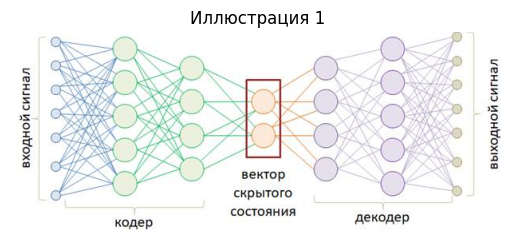

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/AE.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Рассмотрим простейшую модель с линейной функцией активации следующего вида:

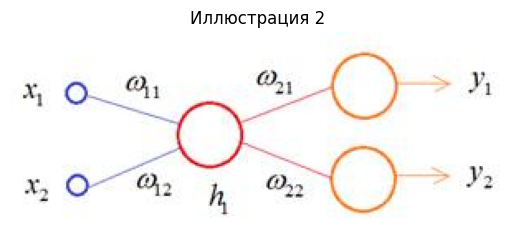

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image2 = mpimg.imread('illustrations/AE_linear.jpg')

plt.imshow(image2)
plt.axis('off')
plt.title('Иллюстрация 2')
plt.show()

В этой схеме кодер выполняет очень простую операцию $h_1=\omega_{11} \cdot x_{1} + \omega_{12} \cdot x_{2}$, а декодер разворачивает значение $h_1$ обратно в двумерный вектор:

$$
\begin{cases}
y_1 = \omega_{21} \cdot h_{1} \\
y_2 = \omega_{22} \cdot h_{1}
\end{cases}
$$

Предположим, что значение $h_1$ — это просто сумма входов:

$$
h_1 = x_1 + x_2 \\
\omega_{11}=\omega_{12} = 1
$$

Затем, декодер пытается восстановить снова эти два значения и делает это, допустим, следующим образом:

$$
\begin{cases}
y_1 = 0.5 \cdot h_{1} \\
y_2 = 0.5 \cdot h_{1}
\end{cases} \\
\omega_{21}=\omega_{22} = 0.5
$$

В результате, получаем модель представления входных данных в скрытом состоянии $h_1$ в виде прямой линии, наклоненной под 45 градусов к осям системы координат:

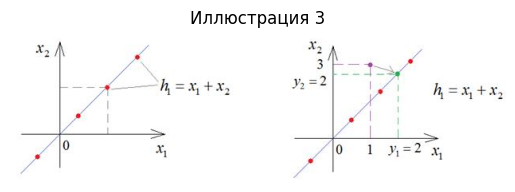

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image3 = mpimg.imread('illustrations/AE_model.jpg')

plt.imshow(image3)
plt.axis('off')
plt.title('Иллюстрация 3')
plt.show()

Пока входные данные соответствуют этой модели, т.е. лежат на этой линии, декодер их точно восстанавливает. Как только их положение меняется, например, 3 и 1, то кодер дает сумму 4 и декодер интерпретирует это значение как 2 и 2. Вот этот момент здесь ключевой: вектор скрытого состояния описывает некую модель представления данных. И чем точнее эта модель описывает входные значения, тем лучше декодер сможет их восстанавливать.

### 2. Реализация автоэнкодера на torch python

In [15]:
import torch
import torch.nn as nn

class AutoEncoderMNIST(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ELU(inplace=True),
            nn.Linear(128, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, self.hidden_dim)
        )
 
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, 128),
            nn.ELU(inplace=True),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        h = self.encoder(x)
        x = self.decoder(h)
 
        return x, h

In [16]:
import torchvision
import torchvision.transforms.v2 as tfs_v2
import torch.utils.data as data

model = AutoEncoderMNIST(28 * 28, 28 * 28, 28)
transforms = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(dtype=torch.float32, scale=True),
                             tfs_v2.Lambda(lambda _img: _img.ravel())])
 
d_train = torchvision.datasets.MNIST('datasets/mnist', download=True, train=True, transform=transforms)
train_data = data.DataLoader(d_train, batch_size=32, shuffle=True)

In [17]:
import torch.optim as optim

optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.MSELoss()
 
epochs = 5
width = len(str(epochs))

model.train()

AutoEncoderMNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ELU(alpha=1.0, inplace=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ELU(alpha=1.0, inplace=True)
    (4): Linear(in_features=64, out_features=28, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ELU(alpha=1.0, inplace=True)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ELU(alpha=1.0, inplace=True)
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
from tqdm import tqdm

for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict, _ = model(x_train)
        loss = loss_func(predict, x_train)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f'Epoch [{_e+1:>{width}d}/{epochs}], loss_mean={loss_mean:.3f}')

model.eval()

st = model.state_dict()
torch.save(st, 'weights/rnn/model_autoencoder_first_1.tar')

Epoch [5/5], loss_mean=0.011: 100%|██████████| 1875/1875 [00:30<00:00, 61.27it/s]


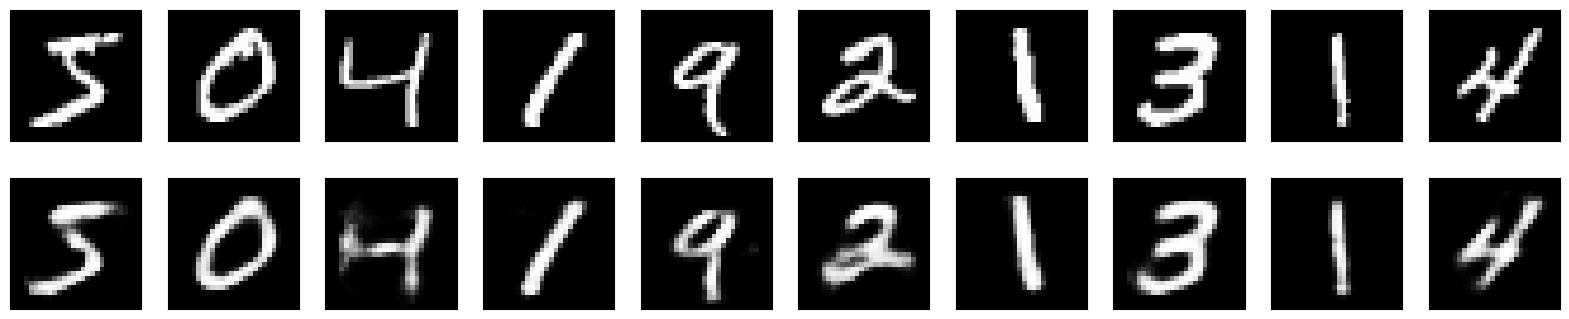

In [19]:
n = 10
 
plt.figure(figsize=(2*n, 2*2))
for i in range(n):
    img, _ = d_train[i]
    predict, _ = model(img.unsqueeze(0))
 
    predict = predict.squeeze(0).view(28, 28)
    img = img.view(28, 28)
 
    dec_img = predict.detach().numpy()
    img = img.detach().numpy()
 
    ax = plt.subplot(2, n, i+1)
    plt.imshow(img, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
 
    ax2 = plt.subplot(2, n, i+n+1)
    plt.imshow(dec_img, cmap='gray')
    ax2.get_xaxis().set_visible(False)
    ax2.get_yaxis().set_visible(False)
 
plt.show()

Как можно объяснить возможность сжатия входного сигнала до вектора в 28 отсчетов? Любое изображение размером 28х28 пикселей можно представить как точку в 784-мерном пространстве. Большинство точек этого пространства будут соответствовать шумовым, непонятным изображениям и только малая их часть соответствует цифрам. Кодер в процессе обучения пытается «уловить» область определения этих цифр в многомерном пространстве и представить их в 28-мерном пространстве вектора скрытого состояния:

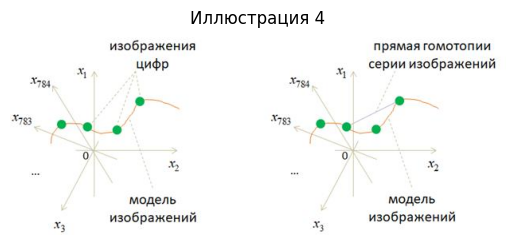

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image4 = mpimg.imread('illustrations/AE_images.jpg')

plt.imshow(image4)
plt.axis('off')
plt.title('Иллюстрация 4')
plt.show()

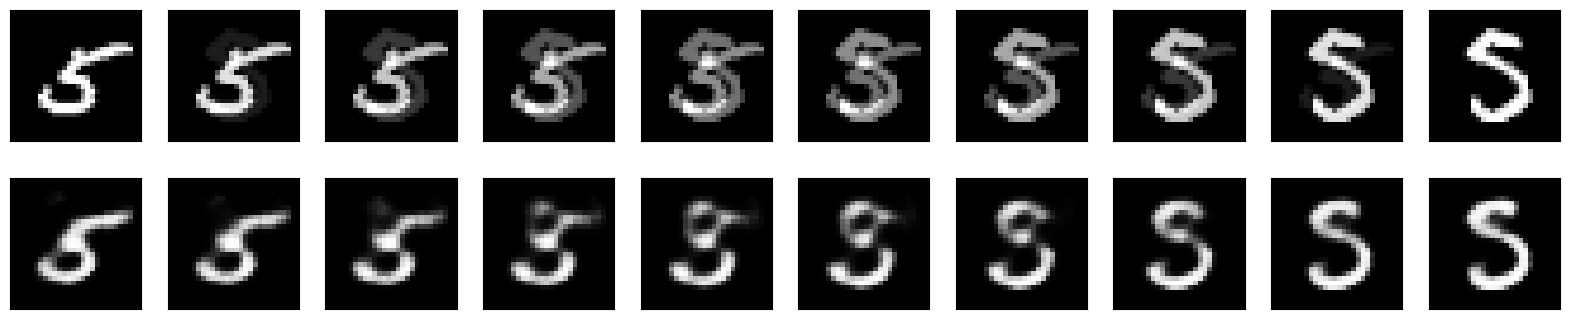

In [ ]:
import numpy as np

st = torch.load('weights/rnn/model_autoencoder_1_dim.tar', weights_only=True)
model.load_state_dict(st)
 
n = 10
model.eval()
 
plt.figure(figsize=(2*n, 2*2))
 
# Фрагмент для формирования и отображения гомотопии изображений по прямой
frm, to = d_train.data[d_train.targets == 5][10:12]
frm = transforms(frm)
to = transforms(to)
 
for i, t in enumerate(np.linspace(0., 1., n)):
    img = frm * (1-t) + to * t  # Гомотопия по прямой
    predict, _ = model(img.unsqueeze(0))
    predict = predict.squeeze(0).view(28, 28)
    dec_img = predict.detach().numpy()
    img = img.view(28, 28).numpy()
 
    ax = plt.subplot(2, n, i+1)
    plt.imshow(img, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
 
    ax2 = plt.subplot(2, n, i+n+1)
    plt.imshow(dec_img, cmap='gray')
    ax2.get_xaxis().set_visible(False)
    ax2.get_yaxis().set_visible(False)
 
plt.show()